# V-JEPA from scratch — the same idea in space *and time*

This builds directly on `01_i-jepa`. The input is now a short **video clip**, the patches
become space-time **tubelets** (a `Conv3d` over 2 frames × 8×8 px), and the mask is a
**tube** (spatial blocks hidden across all frames). Same recipe: encode the visible context,
predict the *embeddings* of the hidden tubes, with an EMA teacher and a stop-gradient.

**About the data.** We make video by **panning a CIFAR-10 image** — each clip is one natural
image translating with a random velocity. Why not, say, a moving MNIST digit? Because a clean
synthetic digit is *linearly trivial*: even a random network reads it off perfectly, so there's
nothing for self-supervised learning to add. Natural image content (as in I-JEPA) is where the
win is real — and indeed our V-JEPA features beat the raw-pixel baseline at object classification,
now learned from video.

**What's in here:** data → 3D tubelet embed → tube masking → predictor → train → linear probe
(object class) vs. a raw-pixel baseline.

In [1]:
import math, copy, time
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- config ---
Tn, H, W = 8, 32, 32            # clip = 8 frames of 32x32 (3 colour channels)
TT, PP = 2, 8                   # tubelet = 2 frames x 8x8 pixels
Tt, Hs, Ws = Tn//TT, H//PP, W//PP   # 4 temporal x 4 x 4 spatial
NTOK = Tt*Hs*Ws                 # 64 tokens
NSP = Hs*Ws                     # 16 spatial positions
DIM, DEPTH, HEADS = 192, 6, 3
PDIM, PDEPTH = 96, 4
EMA_M = 0.996                   # EMA + stop-gradient = the anti-collapse asymmetry (as in real V-JEPA)
EPOCHS = 30
print("device:", DEVICE)

device: cuda


## 1. Data — panning CIFAR-10 clips

Each clip is a single CIFAR-10 image rolled by a random per-clip velocity (a wraparound
pan), so the content is a real natural image and the motion is the predictable structure.
We keep the object class as the label — used only at the end, to probe what was learned.

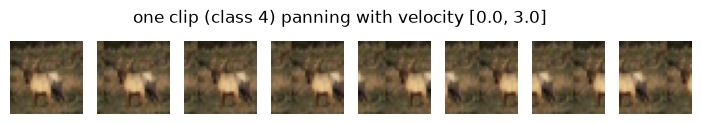

In [2]:
norm = T.Normalize((.4914,.4822,.4465), (.247,.243,.261))
tf = T.Compose([T.ToTensor(), norm])
cifar_tr = tv.datasets.CIFAR10("data", train=True,  download=True, transform=tf)
cifar_te = tv.datasets.CIFAR10("data", train=False, download=True, transform=tf)

class PanningCIFAR(Dataset):
    # clip = a CIFAR image rolled by (vy, vx) per frame; label = class; also expose velocity
    def __init__(self, base): self.base = base
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        img, y = self.base[i]                                       # (3,32,32)
        g = torch.Generator().manual_seed(i + 1)
        vy = torch.randint(-3, 4, (1,), generator=g).item(); vx = torch.randint(-3, 4, (1,), generator=g).item()
        clip = torch.stack([torch.roll(img, shifts=(vy*t, vx*t), dims=(1,2)) for t in range(Tn)], dim=1)  # (3,T,H,W)
        return clip, y, torch.tensor([vy, vx], dtype=torch.float32)

train_set = PanningCIFAR(cifar_tr); test_set = PanningCIFAR(cifar_te)
train_loader = DataLoader(train_set, 128, shuffle=True, num_workers=6, drop_last=True, pin_memory=True)

# show one clip (de-normalized) panning across frames
clip, label, vel = train_set[3]
inv = clip * torch.tensor([.247,.243,.261]).view(3,1,1,1) + torch.tensor([.4914,.4822,.4465]).view(3,1,1,1)
fig, ax = plt.subplots(1, Tn, figsize=(Tn*1.1, 1.4))
for t in range(Tn): ax[t].imshow(inv[:,t].permute(1,2,0).clamp(0,1)); ax[t].axis("off")
fig.suptitle(f"one clip (class {label}) panning with velocity {vel.tolist()}"); plt.show()

## 2. Space-time encoder (3D tubelet ViT) + tube masking

A `Conv3d` with a tubelet kernel turns the clip into tokens, each covering 2 frames × an
8×8 patch. **Tube masking** picks spatial blocks and hides them across *all* frames, so the
model must use the visible regions to infer the hidden tube's embedding.

In [3]:
class Block(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n2 = nn.LayerNorm(dim); self.mlp = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim))
    def forward(self, x):
        y = self.n1(x); x = x + self.attn(y, y, y, need_weights=False)[0]
        return x + self.mlp(self.n2(x))

class ViT3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch = nn.Conv3d(3, DIM, (TT,PP,PP), (TT,PP,PP))      # 3 colour channels in
        self.pos = nn.Parameter(torch.zeros(1, NTOK, DIM)); nn.init.trunc_normal_(self.pos, std=.02)
        self.blocks = nn.ModuleList([Block(DIM, HEADS) for _ in range(DEPTH)]); self.norm = nn.LayerNorm(DIM)
    def forward(self, clip, keep_idx=None):
        x = self.patch(clip).flatten(2).transpose(1, 2) + self.pos  # B,NTOK,DIM (order Tt,Hs,Ws)
        if keep_idx is not None: x = x[:, keep_idx]
        for b in self.blocks: x = b(x)
        return self.norm(x)

def sample_tube_mask(n_blocks=2, scale=(0.2,0.35), aspect=(0.75,1.5)):
    sp = torch.zeros(Hs, Ws, dtype=torch.bool)
    for _ in range(n_blocks):
        s = (scale[0]+torch.rand(1).item()*(scale[1]-scale[0]))*NSP
        ar = aspect[0]+torch.rand(1).item()*(aspect[1]-aspect[0])
        h = max(1,min(Hs,round(math.sqrt(s*ar)))); w = max(1,min(Ws,round(math.sqrt(s/ar))))
        top = torch.randint(0,Hs-h+1,(1,)).item(); left = torch.randint(0,Ws-w+1,(1,)).item()
        sp[top:top+h, left:left+w] = True
    sp = sp.flatten()
    if sp.all(): sp[0] = False
    if not sp.any(): sp[NSP-1] = True
    tok = torch.arange(NTOK)                                        # token order Tt,Hs,Ws
    tgt = sp[tok % NSP]                                             # mask this spatial column across all frames
    return tok[~tgt].to(DEVICE), tok[tgt].to(DEVICE)

## 3. The predictor (unchanged from I-JEPA)

Identical to the image case — a narrow ViT that fills in mask tokens at the target
positions and predicts their embeddings.

In [4]:
class Predictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(DIM, PDIM)
        self.pos = nn.Parameter(torch.zeros(1, NTOK, PDIM)); nn.init.trunc_normal_(self.pos, std=.02)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, PDIM)); nn.init.trunc_normal_(self.mask_token, std=.02)
        self.blocks = nn.ModuleList([Block(PDIM, HEADS) for _ in range(PDEPTH)])
        self.norm = nn.LayerNorm(PDIM); self.out = nn.Linear(PDIM, DIM)
    def forward(self, ctx_repr, ctx_idx, tgt_idx):
        B = ctx_repr.size(0)
        x = self.embed(ctx_repr) + self.pos[:, ctx_idx]
        m = (self.mask_token + self.pos[:, tgt_idx]).expand(B, -1, -1)
        x = torch.cat([x, m], dim=1)
        for b in self.blocks: x = b(x)
        return self.out(self.norm(x)[:, ctx_repr.size(1):])

## 4. Putting it together

Same three networks and the same EMA + stop-gradient asymmetry — the anti-collapse
mechanism real V-JEPA relies on. The only differences from I-JEPA are the 3D patch embed
and the tube mask.

In [5]:
class VJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.context = ViT3D(); self.target = copy.deepcopy(self.context)
        for p in self.target.parameters(): p.requires_grad_(False)
        self.predictor = Predictor()
    @torch.no_grad()
    def ema_update(self, m=EMA_M):
        for pt, pc in zip(self.target.parameters(), self.context.parameters()):
            pt.mul_(m).add_(pc, alpha=1-m)
    def forward(self, clip):
        ci, ti = sample_tube_mask()
        ctx = self.context(clip, keep_idx=ci)                       # encode visible tubes
        pred = self.predictor(ctx, ci, ti)                          # predict hidden tubes
        with torch.no_grad(): tgt = self.target(clip)[:, ti]        # teacher targets (stop-grad)
        return F.smooth_l1_loss(pred, tgt)

model = VJEPA().to(DEVICE)
print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters, {NTOK} tokens/clip")

6.0M parameters, 64 tokens/clip


## 5. Train

Same loop as I-JEPA: encode visible context, predict the hidden tubes' embeddings,
smooth-L1 loss, EMA the teacher.

epoch  1/30  latent loss 0.0993  (5.4s)


epoch  2/30  latent loss 0.0873  (5.2s)


epoch  3/30  latent loss 0.1029  (5.2s)


epoch  4/30  latent loss 0.1144  (5.2s)


epoch  5/30  latent loss 0.1043  (5.2s)


...

epoch 26/30  latent loss 0.0265  (5.2s)


epoch 27/30  latent loss 0.0265  (5.2s)


epoch 28/30  latent loss 0.0270  (5.2s)


epoch 29/30  latent loss 0.0276  (5.2s)


epoch 30/30  latent loss 0.0277  (5.2s)


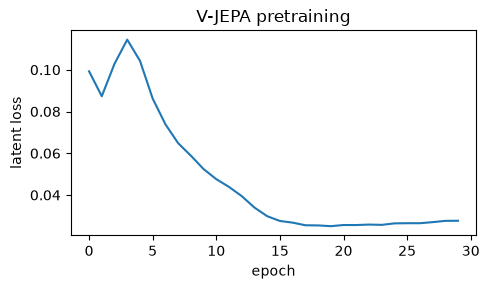

In [6]:
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1.5e-3, weight_decay=.05)
losses = []
for ep in range(EPOCHS):
    model.train(); t = time.time(); tot = 0; nb = 0
    for clip, _, _ in train_loader:
        clip = clip.to(DEVICE, non_blocking=True)
        loss = model(clip)
        opt.zero_grad(); loss.backward(); opt.step(); model.ema_update()
        tot += loss.item(); nb += 1
    losses.append(tot/nb)
    print(f"epoch {ep+1:2d}/{EPOCHS}  latent loss {tot/nb:.4f}  ({time.time()-t:.1f}s)")

plt.figure(figsize=(5,3)); plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("latent loss")
plt.title("V-JEPA pretraining"); plt.tight_layout(); plt.show()

## 6. Evaluate — a linear probe on object class

Exactly the I-JEPA protocol, now on clips: freeze the encoder, mean-pool the clip's tokens,
and train a linear classifier for the object class. We compare against a linear probe on the
**raw clip pixels** — the same honest baseline. Because the content is natural images, raw
pixels aren't linearly separable into classes, so beating that baseline is real evidence the
encoder learned semantic structure from video.

In [7]:
@torch.no_grad()
def encode_features(dataset):
    model.eval(); xs, ys = [], []
    for clip, y, _ in DataLoader(dataset, 256, num_workers=6):
        xs.append(model.context(clip.to(DEVICE)).mean(1).cpu()); ys.append(y)
    return torch.cat(xs), torch.cat(ys)

def linear_probe(Xtr, Ytr, Xte, Yte, steps=1500):
    mu, sd = Xtr.mean(0, keepdim=True), Xtr.std(0, keepdim=True) + 1e-6
    Xtr, Xte = ((Xtr-mu)/sd).to(DEVICE), ((Xte-mu)/sd).to(DEVICE); Ytr, Yte = Ytr.to(DEVICE), Yte.to(DEVICE)
    clf = nn.Linear(Xtr.size(1), 10).to(DEVICE); o = torch.optim.AdamW(clf.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(steps): o.zero_grad(); F.cross_entropy(clf(Xtr), Ytr).backward(); o.step()
    return (clf(Xte).argmax(1) == Yte).float().mean().item()

Xtr, Ytr = encode_features(train_set); Xte, Yte = encode_features(test_set)
acc = linear_probe(Xtr, Ytr, Xte, Yte)

# raw-pixel baseline: flatten the whole clip (3 x T x H x W)
@torch.no_grad()
def raw_features(dataset):
    xs, ys = [], []
    for clip, y, _ in DataLoader(dataset, 256, num_workers=6):
        xs.append(clip.reshape(clip.size(0), -1)); ys.append(y)
    return torch.cat(xs), torch.cat(ys)
Rtr, RYtr = raw_features(train_set); Rte, RYte = raw_features(test_set)
accb = linear_probe(Rtr, RYtr, Rte, RYte, steps=500)

print(f"linear-probe accuracy (V-JEPA features): {acc*100:.1f}%")
print(f"linear-probe accuracy (raw clip pixels): {accb*100:.1f}%")
print(f"random guessing:                         10.0%")

linear-probe accuracy (V-JEPA features): 47.7%
linear-probe accuracy (raw clip pixels): 36.0%
random guessing:                         10.0%


## 7. What we learned

- **Space-time is the same idea.** Tubelets + tube masking + latent prediction — V-JEPA is
  I-JEPA with a time axis. The objective never changed.
- **The win is real on natural content.** Frozen V-JEPA features beat the raw-pixel probe at
  object classification, learned purely from unlabeled clips — the video version of I-JEPA's result.
- **Data matters as much as the model.** Our first attempt used clean synthetic Moving-MNIST and
  *couldn't* show a win: a clean digit is linearly trivial, so a random network already reads it
  off and there's nothing for learning to add. Switching to natural-image clips is what made the
  self-supervised signal measurable — a genuinely useful lesson about evaluating SSL.
- **Anti-collapse, briefly.** The EMA + stop-gradient asymmetry keeps the trivial all-identical
  solution at bay. At scale, variance/covariance (VICReg) or LeJEPA's SIGReg add an explicit safety
  net — see the course's CollapseLab for why.
- **Scale honesty.** Real V-JEPA 2 is a >1B-param ViT-g on 1M+ hours of video. Here it's a toy on
  panning CIFAR — but the space-time mechanism is the genuine article.